In [2]:
# import pandas, numpy
import pandas as pd
import numpy as np

import scipy.stats as stats

# Data Visualization
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px

# import sklearn modules functions.
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

# import sklearn modules classes.
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [9]:
# create a DataFrame
df = pd.read_csv('train.csv', usecols=['Age', 'Fare', 'Survived'])
# Check for Null
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [11]:
# fillna()
df['Age'].fillna(df['Age'].mean(), inplace=True)

In [12]:
df.head(5)

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [14]:
# Get the required columns
X = df.iloc[:,1:3]
y = df.iloc[:,0]

In [56]:
# from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
    y, 
    test_size = 0.2,
    random_state = 42
)

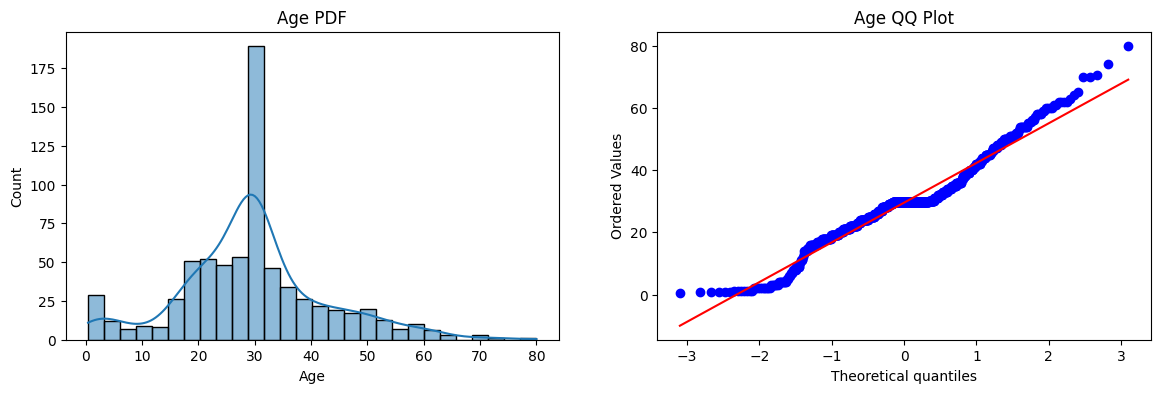

In [57]:
# Creating a single graph
plt.figure(figsize=(14, 4))
# plot-1 
plt.subplot(121)
sns.histplot(X_train['Age'], kde=True)
plt.title('Age PDF')

# plot-2
plt.subplot(122)
stats.probplot(X_train['Age'], dist='norm', plot=plt)
plt.title('Age QQ Plot')

# show
plt.show()

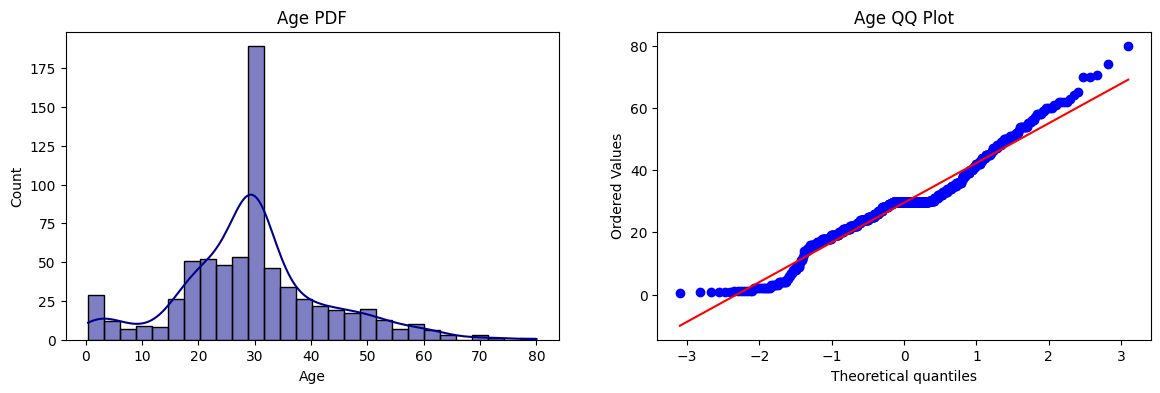

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# plot-1
sns.histplot(X_train['Age'], kde=True, ax=axes[0], color='darkblue')
axes[0].set_title('Age PDF')

# plot-2
stats.probplot(X_train['Age'], dist='norm', plot=axes[1])
axes[1].set_title('Age QQ Plot')

# show graph
plt.show()

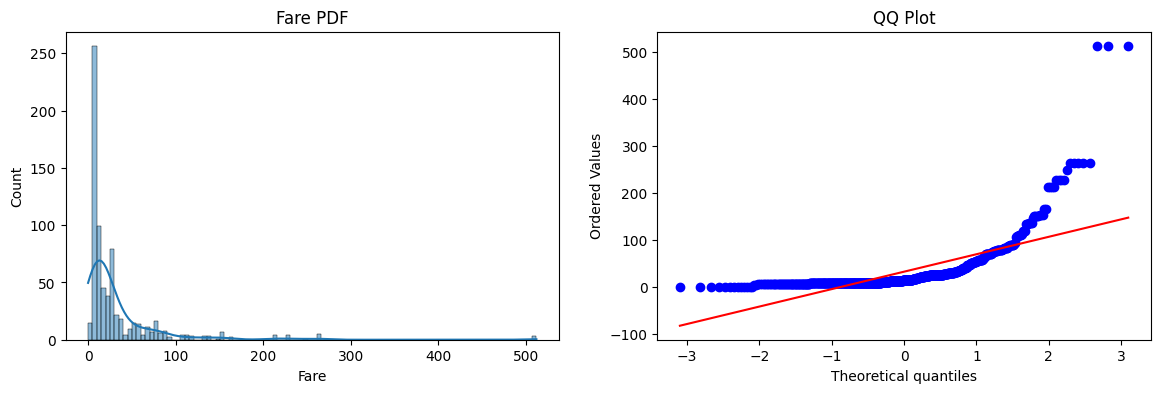

In [59]:
# Check Normality for Fare Column
fig, axes = plt.subplots(1, 2, figsize=(14,4))

# plot-1
sns.histplot(X_train['Fare'], kde=True, ax=axes[0])
axes[0].set_title('Fare PDF')

# plot-2
stats.probplot(X_train['Fare'], plot=axes[1])
axes[1].set_title('QQ Plot')

# show plot
plt.show()

In [62]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [64]:
# Model fitting
# logistic fitting
clf.fit(X_train, y_train)
clf2.fit(X_train, y_train) 

# predict data
y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

# Get accuracy for the model
print("Accuracy LR", accuracy_score(y_test, y_pred))
print("Accuracy DT", accuracy_score(y_test, y_pred1))

Accuracy LR 0.6480446927374302
Accuracy DT 0.6759776536312849


In [68]:
# Function_Transformer
trf = FunctionTransformer(func=np.log1p)

In [69]:
X_train_trans = trf.fit_transform(X_train)
X_test_trans = trf.fit_transform(X_test)

In [70]:
# Model fitting --> After FunctionTransformer

# logistic fitting
clf.fit(X_train_trans, y_train)
# DecisionTreeClassifier
clf2.fit(X_train_trans, y_train) 

# predict data
y_pred = clf.predict(X_test_trans)
y_pred1 = clf2.predict(X_test_trans)

# Get accuracy for the model
print("Accuracy LR", accuracy_score(y_test, y_pred))
print("Accuracy DT", accuracy_score(y_test, y_pred1))

Accuracy LR 0.6815642458100558
Accuracy DT 0.6871508379888268


In [75]:
X.sample()

,Age,Fare
88,23.0,263.0


In [78]:
X_transformed = trf.fit_transform(X)

# LogisticRegression Object
clf = LogisticRegression()
# Create Object of DecisionTreeClassifier
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf, X_transformed, y, scoring='accuracy', cv=10)))
print("LR",np.mean(cross_val_score(clf2, X_transformed, y, scoring='accuracy', cv=10)))

LR 0.678027465667915
LR 0.658876404494382


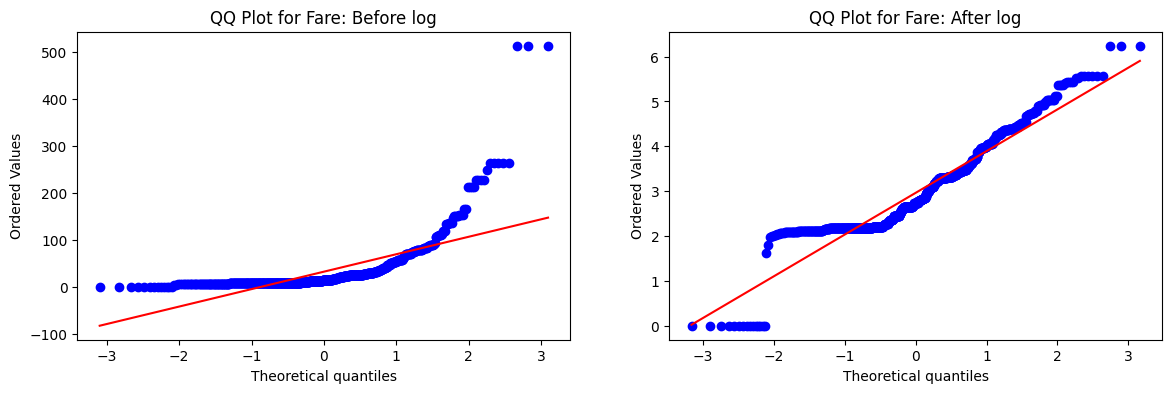

In [83]:
# Create graph
fig, axes = plt.subplots(1, 2, figsize=(14,4))

# plot-1
stats.probplot(X_train['Fare'], plot=axes[0])
axes[0].set_title('QQ Plot for Fare: Before log')

# plot-2
stats.probplot(X_transformed['Fare'], plot=axes[1])
axes[1].set_title('QQ Plot for Fare: After log')

# show graph
plt.show()

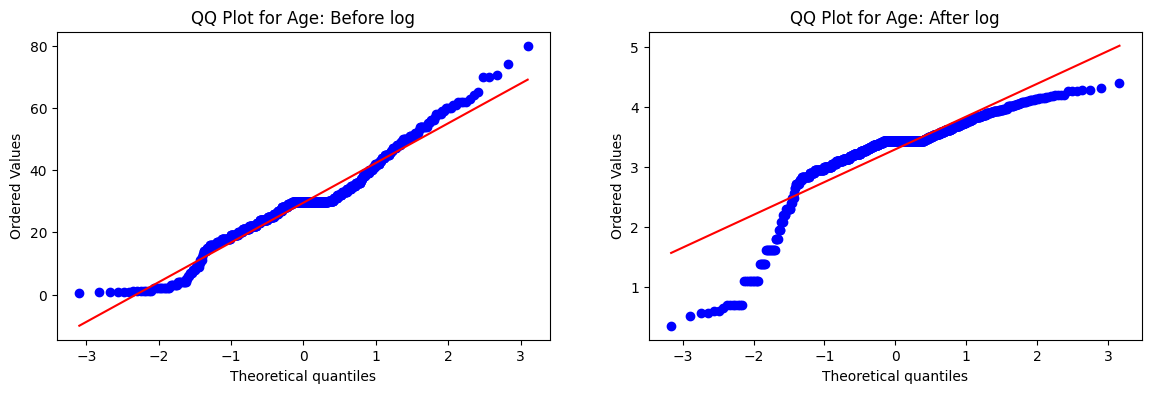

In [86]:
# Age-Column
plt.figure(figsize=(14,4))

# plot-1
plt.subplot(121)
stats.probplot(X_train['Age'], dist='norm', plot=plt)
plt.title('QQ Plot for Age: Before log')

# plot-2
plt.subplot(122)
stats.probplot(X_transformed['Age'], dist='norm', plot=plt)
plt.title('QQ Plot for Age: After log')

# show graph
plt.show()

In [89]:
trf2 = ColumnTransformer([('log', FunctionTransformer(np.log1p), ['Fare'])], remainder='passthrough')

X_train_trans2 = trf2.fit_transform(X_train)
X_test_trans2 = trf2.fit_transform(X_test)

In [92]:
# Model fitting --> After FunctionTransformer for Fare Only.

# logistic fitting
clf.fit(X_train_trans2, y_train)
# DecisionTreeClassifier
clf2.fit(X_train_trans2, y_train) 

# predict data
y_pred = clf.predict(X_test_trans2)
y_pred1 = clf2.predict(X_test_trans2)

# Get accuracy for the model
print("Accuracy LR", accuracy_score(y_test, y_pred))
print("Accuracy DT", accuracy_score(y_test, y_pred1))

Accuracy LR 0.6703910614525139
Accuracy DT 0.6536312849162011


In [93]:
X_transformed2 = trf.fit_transform(X)

# LogisticRegression Object
clf = LogisticRegression()
# Create Object of DecisionTreeClassifier
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf, X_transformed2, y, scoring='accuracy', cv=10)))
print("LR",np.mean(cross_val_score(clf2, X_transformed2, y, scoring='accuracy', cv=10)))

LR 0.678027465667915
LR 0.6633208489388265


In [96]:
def apply_transform(transform):
    X = df.iloc[:, 1:3]
    y = df.iloc[:, 0]

    trf = ColumnTransformer([('log', FunctionTransformer(np.log1p), ['Fare'])], remainder='passthrough')
    X_trans = trf.fit_transform(X)

    clf = LogisticRegression()

    print("Accuracy", np.mean(cross_val_score(clf, X_trans, y, scoring='accuracy', cv=10)))

    plt.figure(figsize=(14,4))

    # plot-1
    plt.subplot(121)
    stats.probplot(X['Age'], dist='norm', plot=plt)
    plt.title('QQ Plot for Fare: Before log')
    
    # plot-2
    plt.subplot(122)
    stats.probplot(X_trans[:, 0], dist='norm', plot=plt)
    plt.title('QQ Plot for Fare: After log')
    
    # show graph
    plt.show()

Accuracy 0.6712609238451936


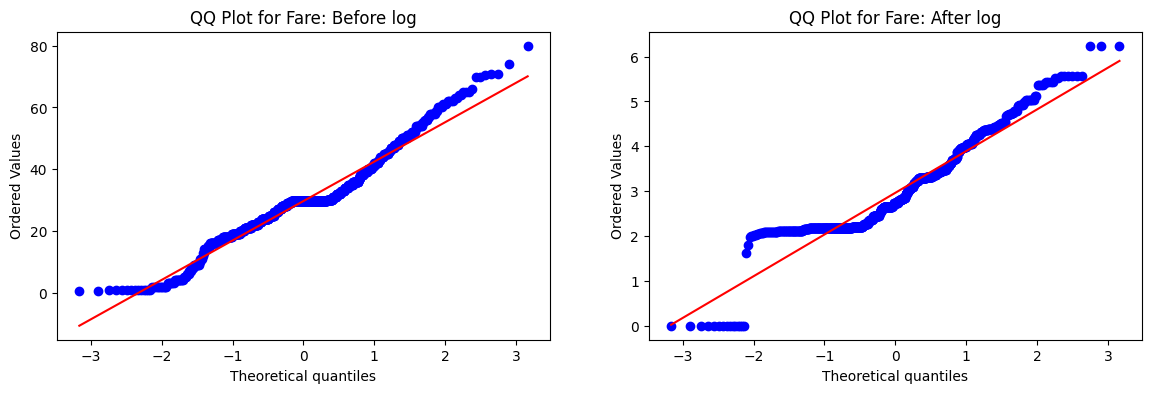

Accuracy 0.6712609238451936


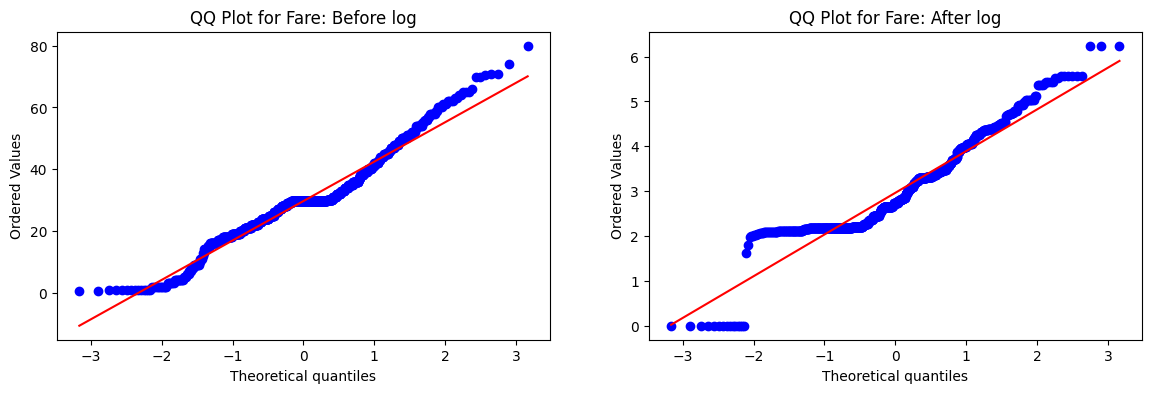

In [103]:
apply_transform(lambda x: x**3),
apply_transform(np.sin(90))